# Beyond the Tribe: Utility-Scale Solar Growth (2014-2024)
Data pull and professional-grade plotting.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import requests
import numpy as np
from matplotlib.patches import Rectangle

# Apply BTT styling
plt.style.use(['Solarize_Light2', 'btt_style'])

In [ ]:
# 1. API CALL (Pulling the full decade once)
# Apply for a key at EIA.gov if you don't have one yet.
EIA_KEY = "EIA_key_name"
URL = "https://api.eia.gov/v2/electricity/electric-power-operational-data/data/"

params = {
    "api_key": EIA_KEY,
    "frequency": "annual",
    "data[0]": "generation",
    "facets[fueltypeid][]": "SUN",
    "facets[sectorid][]": "98",
    "start": "2014",
    "end": "2024",
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",
    "length": 5000 
}

r = requests.get(URL, params=params)
if r.status_code == 200:
    df = pd.DataFrame(r.json()['response']['data'])
    df['generation'] = pd.to_numeric(df['generation'])
    df['period'] = pd.to_datetime(df['period'], format='%Y').dt.year
    print(f"Success! Pulled {len(df)} rows.")
else:
    print(f"Error {r.status_code}: {r.text}")

Success! Pulled 630 rows.


In [33]:
# 2. DATA PROCESSING
states_and_dc = [
    'AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'FL', 'GA', 'HI', 
    'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA', 'MI', 'MN', 
    'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM', 'NY', 'NC', 'ND', 'OH', 
    'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 
    'WV', 'WI', 'WY'
]

df = df[df['location'].isin(states_and_dc)].copy()

# Extract specific years from the main dataframe without extra API calls
gen_2014_map = df[df['period'] == 2014].set_index('location')['generation'].to_dict()
gen_2024_map = df[df['period'] == 2024].set_index('location')['generation'].to_dict()

# Calculate the intensity map
def get_growth_intensity(group):
    if len(group) < 2 or group['generation'].mean() == 0: return 0.0
    slope, _ = np.polyfit(group['period'], group['generation'], 1)
    return (slope / group['generation'].mean()) * 100

intensity_map = df.groupby('location').apply(get_growth_intensity).to_dict()

# Explicitly exclude Alaska 
intensity_map['AK'] = np.nan
intensity_map['ND'] = 0.0

C:\Users\samho\AppData\Local\Temp\ipykernel_20456\1520700024.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  intensity_map = df.groupby('location').apply(get_growth_intensity).to_dict()


In [34]:
# 3. GEODATA SETUP
name_to_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH',
    'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC',
    'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode Island': 'RI', 'South Carolina': 'SC', 'South Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY', 'District of Columbia': 'DC'
}

def shift_to_btt_manual(gdf):
    ak = gdf[gdf['abbr'] == 'AK'].copy()
    hi = gdf[gdf['abbr'] == 'HI'].copy()
    lower_48 = gdf[~gdf['abbr'].isin(['AK', 'HI', 'PR', 'GU', 'VI'])].copy()

    target_x_ak, target_x_hi = -1200000, 600000
    target_y_bottom = -100000 

    curr_hi = hi.geometry.centroid.iloc[0]
    hi.geometry = hi.geometry.translate(xoff=target_x_hi - curr_hi.x, yoff=target_y_bottom - curr_hi.y)

    ak.geometry = ak.geometry.scale(xfact=0.4, yfact=0.4, origin='centroid')
    curr_ak = ak.geometry.centroid.iloc[0]
    ak.geometry = ak.geometry.translate(xoff=target_x_ak - curr_ak.x, yoff=target_y_bottom - curr_ak.y)

    return pd.concat([lower_48, ak, hi])

usa = gpd.read_file("https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json")
usa['abbr'] = usa['name'].map(name_to_abbr)

# Attach all plot data to the geodataframe
usa['gen_2014'] = usa['abbr'].map(gen_2014_map).fillna(0)
usa['gen_2024'] = usa['abbr'].map(gen_2024_map).fillna(0)
usa['intensity'] = usa['abbr'].map(intensity_map)

final_map = shift_to_btt_manual(usa[usa['abbr'].isin(states_and_dc)].to_crs(epsg=5070))

In [35]:
# 4. MASTER PLOTTING ENGINE
def generate_btt_map(column_name, title, cbar_label, filename, vmax=None):
    fig, ax = plt.subplots(1, 1, figsize=(10, 11))

    final_map.plot(
        column=column_name, cmap='YlOrRd', vmax=vmax, linewidth=1.2, ax=ax, edgecolor='#586e75', 
        legend=True, missing_kwds={'color': '#eee8d5'},
        legend_kwds={'orientation': "horizontal", 'pad': 0.08, 'shrink': 0.85, 'aspect': 25}
    )

    cbar_ax = fig.axes[-1]
    cbar_ax.set_xlabel(cbar_label, fontsize=22, fontweight='black', labelpad=8)
    cbar_ax.tick_params(labelsize=16)

    for idx, row in final_map.iterrows():
        if pd.isna(row['abbr']): continue
        x, y = row.geometry.centroid.coords[0]
        
        callouts = {'VT': (x-200000, y+450000), 'NH': (x+500000, y+250000), 'MA': (x+600000, y+100000), 
                    'RI': (x+600000, y-100000), 'CT': (x+600000, y-250000), 'NJ': (x+500000, y-420000), 
                    'DE': (x+500000, y-580000), 'MD': (x+500000, y-730000), 'DC': (x+400000, y-880000)}

        if row['abbr'] in callouts and row['abbr'] != 'ME':
            ax.annotate(text=row['abbr'], xy=(x, y), xytext=callouts[row['abbr']], ha='center', va='center', 
                        fontsize=16, fontweight='black', color='#002b36',
                        arrowprops=dict(arrowstyle='-', connectionstyle="arc3,rad=0.1", color='#586e75', lw=1.5))
        else:
            label_text = row['abbr']

            if row['abbr'] == 'LA': x -= 60000
            elif row['abbr'] == 'FL': x += 70000
            elif row['abbr'] == 'MI': x += 110000; y -= 140000 
            
            ax.annotate(text=label_text, xy=(x, y), ha='center', va='center', 
                        fontsize=18, fontweight='black', color='#002b36')

    # Layout & Framing
    fig.text(0.5, 0.94, title, fontsize=36, fontweight='black', ha='center', va='top', linespacing=1.2)
    fig.text(0.5, 0.04, 'Source: EIA-923 | Beyond the Tribe', ha='center', va='bottom', fontsize=14, alpha=0.6)
    plt.subplots_adjust(left=0.05, right=0.95, top=0.82, bottom=0.12)
    fig.patches.extend([
        Rectangle((0, 0), 1, 1, fill=False, color='black', lw=10, 
                  zorder=1000, transform=fig.transFigure, figure=fig)
    ])
    ax.axis('off')

    # Locked mobile framing
    minx, miny, maxx, maxy = final_map.total_bounds
    ax.set_xlim(minx - 10000, maxx + 280000) 
    ax.set_ylim(miny - 20000, maxy + 20000) 

    plt.savefig(filename, dpi=300, facecolor=fig.get_facecolor())
    plt.show()

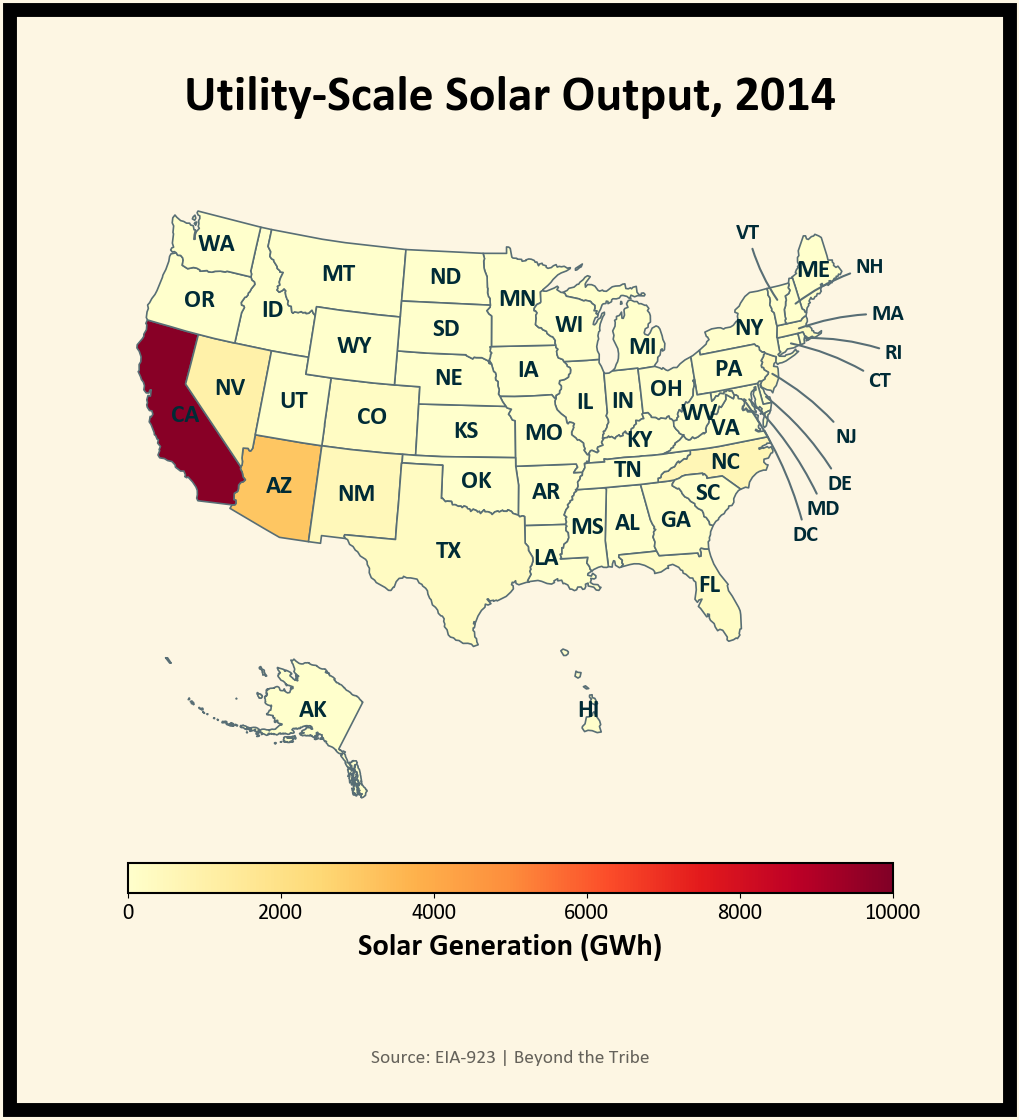

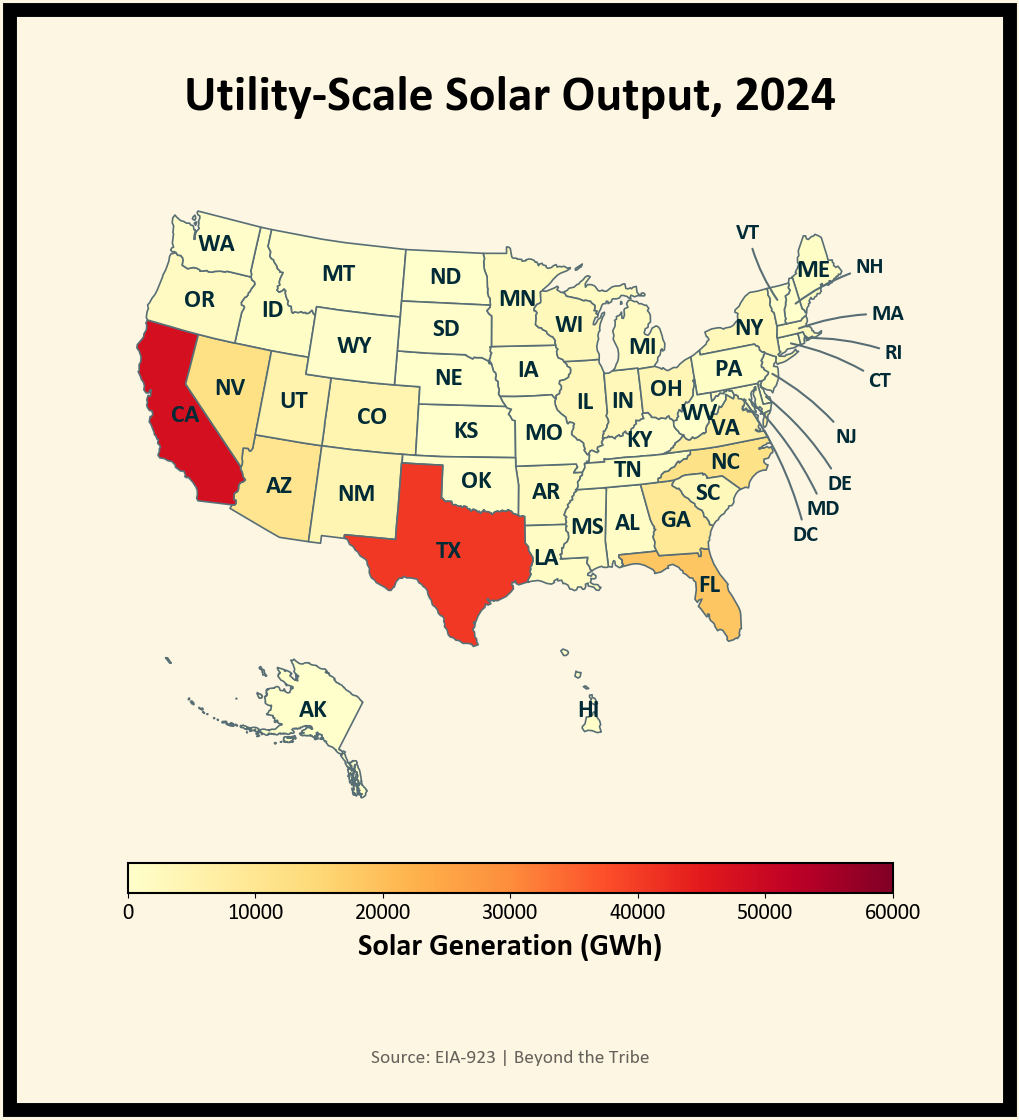

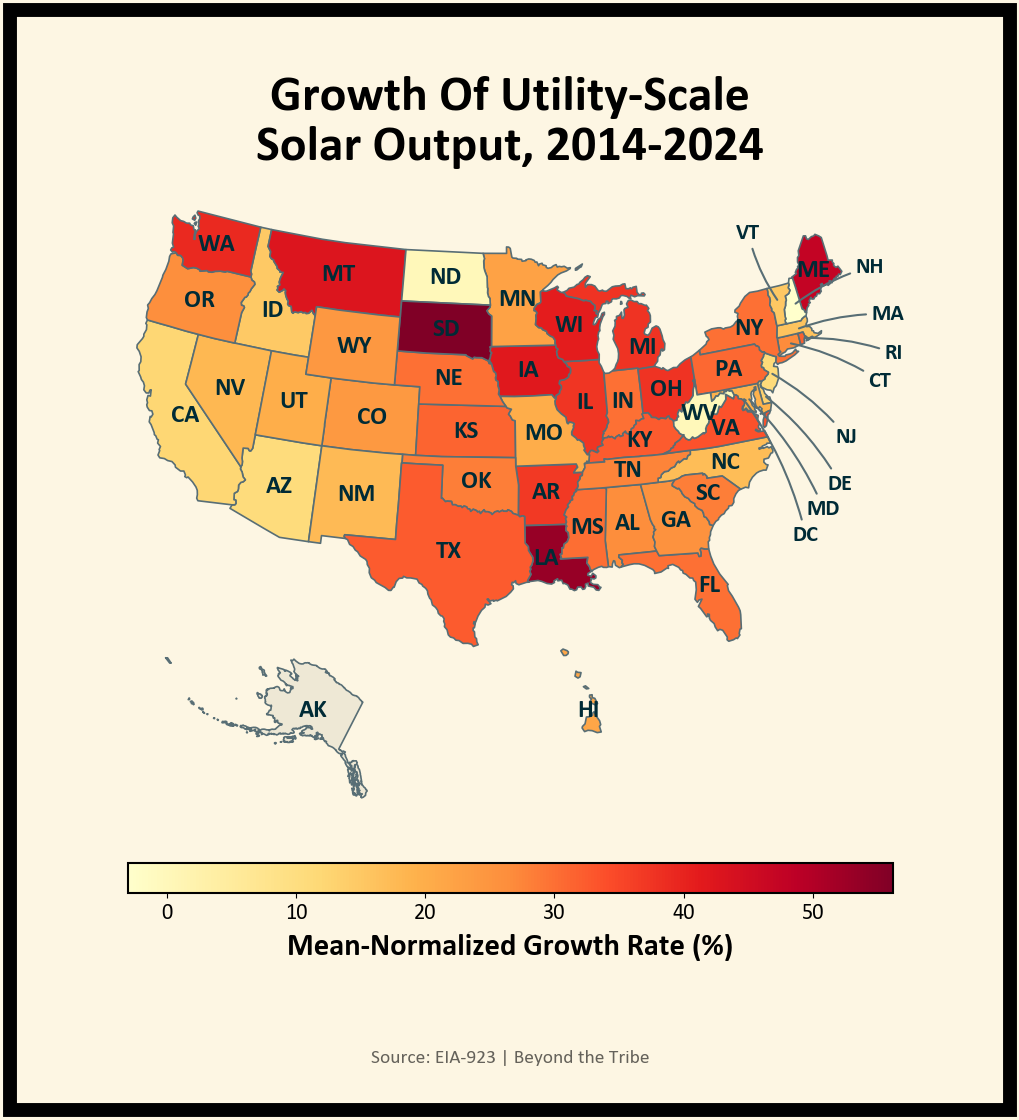

In [36]:
# 5. GENERATE ALL CHARTS

# 2014 Baseline Plot
generate_btt_map(
    column_name='gen_2014', 
    title='Utility-Scale Solar Output, 2014', 
    cbar_label='Solar Generation (GWh)', 
    filename='solar_output_2014.png', 
    vmax=10000
)

# 2024 Output Plot
generate_btt_map(
    column_name='gen_2024', 
    title='Utility-Scale Solar Output, 2024', 
    cbar_label='Solar Generation (GWh)', 
    filename='solar_output_2024.png',
    vmax=60000
)

# Decade Growth Plot
generate_btt_map(
    column_name='intensity', 
    title='Growth Of Utility-Scale\nSolar Output, 2014-2024', 
    cbar_label='Mean-Normalized Growth Rate (%)', 
    filename='solar_growth_2014_to_2024.png'
    # vmax is removed here to allow the true maximum growth to define the colorbar
)